# Step 2: Baseline Model & Metrics That Actually Mean Something

Step 1 showed that accuracy is a trap on this dataset - 99.83% just by always guessing "legitimate". This step trains a real first model (plain **Logistic Regression**, no special handling of the imbalance yet - that's Step 3) and evaluates it with metrics built for exactly this kind of problem: **precision**, **recall**, **F1**, and **ROC-AUC**.

In [1]:
from data_prep import load_data, prepare_split

df = load_data()
X_train, X_test, y_train, y_test = prepare_split(df)

print("Training fraud rate:", f"{y_train.mean()*100:.3f}%")
print("Test fraud rate:", f"{y_test.mean()*100:.3f}%")

Training fraud rate: 0.167%
Test fraud rate: 0.167%


Both splits keep almost exactly the same ~0.167% fraud rate - that's `stratify=y` doing its job (see [`data_prep.py`](data_prep.py) for why that matters here more than in a balanced dataset).

## Training the baseline

In [2]:
from models import train_logistic_regression

baseline = train_logistic_regression(X_train, y_train)

y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]  # probability of being fraud
print("Trained.")

Trained.


Deliberately **no special imbalance handling yet** - this model was trained exactly as if the classes were balanced. That's the point of a baseline: see what the plainest reasonable approach gets you, before adding complexity in Step 3.

## First, the misleading number

In [3]:
from sklearn.metrics import accuracy_score

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.3f}%")
print(f"(the naive 'always legitimate' baseline from Step 1 was 99.833%)")

Accuracy: 99.914%
(the naive 'always legitimate' baseline from Step 1 was 99.833%)


Barely better than doing nothing. This is why accuracy alone is meaningless here - it can't tell a genuinely useful fraud detector apart from a lazy do-nothing model. Time for metrics that can.

## The confusion matrix: where the model is actually right or wrong

Four numbers, for a binary problem:
- **True Positives (TP):** real fraud, correctly flagged.
- **False Positives (FP):** legitimate transaction, wrongly flagged as fraud (annoys a real customer, e.g. a blocked card).
- **True Negatives (TN):** legitimate, correctly left alone.
- **False Negatives (FN):** real fraud that slipped through undetected (the costly kind of mistake for a bank).

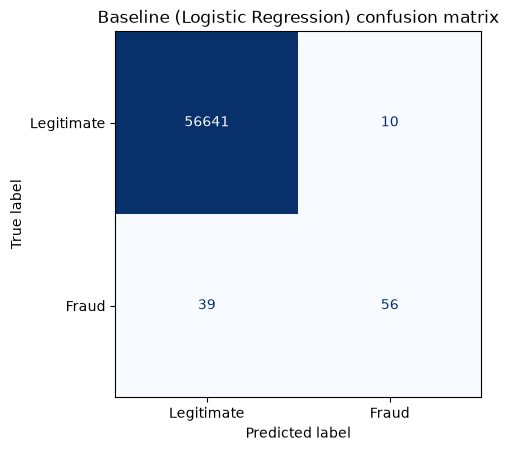

True Negatives:  56641
False Positives: 10
False Negatives: 39
True Positives:  56


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Legitimate", "Fraud"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Baseline (Logistic Regression) confusion matrix")
plt.tight_layout()
plt.savefig("assets/baseline_confusion_matrix.png", dpi=120)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}\nFalse Positives: {fp}\nFalse Negatives: {fn}\nTrue Positives:  {tp}")

## Precision, recall, and F1

- **Precision** = TP / (TP + FP): of everything the model *flagged* as fraud, how much really was fraud? Low precision means lots of false alarms - real customers getting blocked for no reason.
- **Recall** = TP / (TP + FN): of all the *real* fraud cases, how many did the model actually catch? Low recall means fraud slipping through undetected.
- These two usually trade off against each other (more on that in Step 5) - **F1** is their harmonic mean, a single number that only looks good when both precision and recall are reasonably good, not just one of them.

In [5]:
from models import evaluate

metrics = evaluate(baseline, X_test, y_test)
precision, recall, f1, roc_auc = metrics["precision"], metrics["recall"], metrics["f1"], metrics["roc_auc"]

print(f"Precision: {precision*100:.1f}%  - of flagged transactions, this % really were fraud")
print(f"Recall:    {recall*100:.1f}%  - of real fraud cases, this % got caught")
print(f"F1 score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

Precision: 84.8%  - of flagged transactions, this % really were fraud
Recall:    58.9%  - of real fraud cases, this % got caught
F1 score:  0.696
ROC-AUC:   0.956


**What is ROC-AUC?** Precision and recall both depend on a specific decision threshold ("flag as fraud if predicted probability > 50%"). ROC-AUC instead measures how well the model *ranks* fraud above legitimate transactions across every possible threshold at once - a value of 1.0 means perfect ranking, 0.5 means no better than random guessing. It's a good single number for comparing models before committing to any particular threshold (which Step 5 looks at properly).

## Reading this baseline honestly

84.8% precision is decent - most fraud alerts are real. But **58.9% recall means over 4 in 10 real fraud cases go undetected** by this baseline. For an actual bank, that gap is exactly what Step 3 (imbalance handling) and Step 4 (a stronger model) will try to close - a fraud detector that misses more than a third of fraud isn't good enough yet, even though its accuracy number (99.9%) looks nearly perfect.

## Summary

| Metric | Value |
|---|---|
| Accuracy | 99.91% (misleading - barely beats doing nothing) |
| Precision | 84.8% |
| Recall | 58.9% |
| F1 | 0.696 |
| ROC-AUC | 0.956 |

A real, working baseline - but with meaningful room to improve, especially on recall. Next: Step 3 explicitly addresses the class imbalance instead of ignoring it, and checks whether that closes the gap.